10.2 Exercise 1
 
(a) Ensemble accuracy with 15 models at 63%: 0.8512830492077244
(b) Minimum individual accuracy needed: 71 %
(c) Minimum number of models needed: 39
 
 
10.2 Exercise 2
 
PMF sums to: 1.0000000000000002


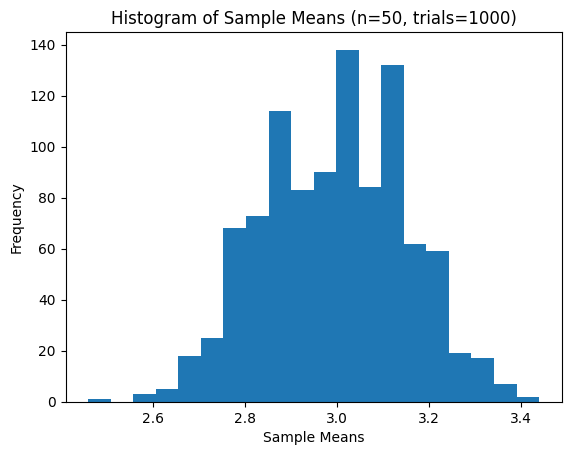


Shape of histogram: Approximately normal (bell-shaped)
Theorem: Central Limit Theorem explains this shape.

Empirical Mean of sample means: 2.9967599999999996
Empirical Std Dev of sample means: 0.15505064462942428

Theoretical Mean: 3.0
Theoretical Std Dev: 0.15491933384829668


In [ ]:
# ================================================================
# Title: 10.2 Exercise 1
# Author: ChanaOchs126 (GitHub username)
# Date: 3/4/2026
# Modified By: Cyndie Cramer
# Description: Using the Binomial Distribution
# =================================================================

print("10.2 Exercise 1")
print(" ")

# Import the needed library
from scipy.stats import binom

# Function to compute ensemble accuracy given:
# n = number of models
# p = individual model accuracy
def ensemble_accuracy(n, p):
    # Majority vote threshold
    k = n // 2 + 1
    # Probability that at least k models are correct
    return 1 - binom.cdf(k - 1, n, p)


# (a) Ensemble accuracy with 15 models, each 63% accurate
n = 15
p = 0.63
acc_a = ensemble_accuracy(n, p)
print("(a) Ensemble accuracy with 15 models at 63%:", acc_a)


# (b) Minimum individual accuracy needed for ensemble to reach 95%
target_accuracy = 0.95
n = 15

min_p = None
for percent in range(50, 101):  # search from 50% to 100%
    p = percent / 100
    if ensemble_accuracy(n, p) >= target_accuracy:
        min_p = percent
        break

print("(b) Minimum individual accuracy needed:", min_p, "%")


# (c) Minimum number of models needed (odd number), each 63% accurate,
#     for ensemble accuracy to reach 95%
target_accuracy = 0.95
p = 0.63

min_n = None
for n in range(1, 201, 2):  # odd numbers only
    if ensemble_accuracy(n, p) >= target_accuracy:
        min_n = n
        break

print("(c) Minimum number of models needed:", min_n)


# ================================================================
# Title: 10.2 Exercise 2
# Author: Vivekdash123 (GitHub username)
# Date: 3/4/2026
# Modified By: Cyndie Cramer
# Description: Working with Random Data
# =================================================================

print(" ")
print(" ")
print("10.2 Exercise 2")
print(" ")

# Import the needed libraries.
import numpy as np
import matplotlib.pyplot as plt


# (a) Define PMF for X
# X can take values 1,2,3,4,5
values = np.array([1, 2, 3, 4, 5])

# Valid PMF (must sum to 1)
probabilities = np.array([0.10, 0.20, 0.40, 0.20, 0.10])

# Verify PMF validity
print("PMF sums to:", np.sum(probabilities))


# (b) Function to generate 50 X values and return mean
def sample_mean(n_samples=50):
    samples = np.random.choice(values, size=n_samples, p=probabilities)
    return np.mean(samples)


# (c) Function to run part (b) 1000 times
def generate_means(num_trials=1000, n_samples=50):
    means = []
    for _ in range(num_trials):
        means.append(sample_mean(n_samples))
    return means


# Generate list of 1000 sample means
means_list = generate_means(num_trials=1000, n_samples=50)


# (d) Create histogram
plt.figure()
plt.hist(means_list, bins=20)
plt.xlabel("Sample Means")
plt.ylabel("Frequency")
plt.title("Histogram of Sample Means (n=50, trials=1000)")
plt.show()

print("\nShape of histogram: Approximately normal (bell-shaped)")
print("Theorem: Central Limit Theorem explains this shape.")


# (e) Empirical vs Theoretical values
# Empirical statistics
empirical_mean = np.mean(means_list)
empirical_std = np.std(means_list)

# Theoretical mean of X
theoretical_mean = np.sum(values * probabilities)

# Theoretical variance of X
theoretical_variance = np.sum((values - theoretical_mean)**2 * probabilities)

# Theoretical std of sampling distribution
theoretical_std = np.sqrt(theoretical_variance / 50)

print("\nEmpirical Mean of sample means:", empirical_mean)
print("Empirical Std Dev of sample means:", empirical_std)

print("\nTheoretical Mean:", theoretical_mean)
print("Theoretical Std Dev:", theoretical_std)